# **Exploratory Analysis and Regression Modelling of Texas Bridge Data**
<div align="center">

### Texas Department of Transportation - Bridge Inventory Dataset (2019) 

</div>

<div align="center"> 

**Author:** Cipriano Gertrudes Sebastiao &emsp; &emsp; &emsp; &emsp; **Email:** ciprianogertrudes@gmail.com 

</div>

<hr style="height:2px; border:none; background-color: #3498db;">

## Executive Summary

This report presents a statistical analysis of 34,293 bridges recorded in the Texas Department of Transportation inventory. The objective is to determine which of five candidate variables among bridge age, average daily traffic, truck percentage, construction material, and structural design, best predicts the overall structural condition of a bridge.

Condition is measured as a score (0–27) summed from three independent inspector ratings: deck, superstructure, and substructure. The analysis unfolds in three stages: data preparation, exploratory analysis, and linear regression modelling. 

The most significant finding is that **bridge age is the strongest predictor of structural condition**, explaining approximately 35% of the variation, while variables related to traffic show negligible influence.

<hr style="height:2px; border:none; background-color: #3498db;">

## Table of Contents

1. [Setup](#setup)

2. [Part 1: Data Preparation](#part-1-data-preparation)
   - 1.1 [Loading and Inspecting the Data](#11-loading-and-inspecting-the-data)
   - 1.2 [Deriving the Age Variable](#12-deriving-the-age-variable)
   - 1.3 [Constructing the Condition Score](#13-constructing-the-condition-score)
   - 1.4 [Simplifying Categorical Variables](#14-simplifying-categorical-variables)
   - 1.5 [Excluding Historic Bridges](#15-excluding-historic-bridges)

3. [Part 2: Exploratory Data Analysis](#part-2-exploratory-data-analysis)
   - 2.1 [Distribution of the Condition Score](#21-distribution-of-the-condition-score)
   - 2.2 [Continuous Predictors vs Condition](#22-continuous-predictors-vs-condition)
   - 2.3 [Categorical Predictors vs Condition](#23-categorical-predictors-vs-condition)
   - 2.4 [Relationships Between Predictors](#24-relationships-between-predictors)
   - 2.5 [Preliminary Conclusions](#25-preliminary-conclusions)

4. [Part 3: Regression Modelling](#part-3-regression-modelling)
   - 3.1 [Model Construction](#31-model-construction)
   - 3.2 [Model Performance](#32-model-performance)
   - 3.3 [Residual Analysis](#33-residual-analysis)
   - 3.4 [Predictor Influence](#34-predictor-influence)
   - 3.5 [Final Conclusions](#35-final-conclusions)


<hr style="height:2px; border:none; background-color: #3498db;">

### Setup

The following libraries are used throughout this analysis:
- **pandas / numpy**: data loading and manipulation
- **matplotlib / seaborn**: visualisation
- **scipy**: statistical tests (Pearson correlation, one-way ANOVA)
- **scikit-learn**: linear regression modelling and error metrics

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from scipy.stats import pearsonr, f_oneway
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

%matplotlib inline
sns.set_style("whitegrid")

## Part 1: Data Preparation

### 1.1 Loading and Inspecting the Data

This initial process involves loading the raw data and transform it into a suitable format for regression analysis. The main task is to create the 'Age' and 'Condition' variables as well as handling missing or unusable data.

In [2]:
# Load dataset from CSV file
data = pd.read_csv('tx19_bridges_sample.csv')
data

,Structure_id,District,Detour_Km,Toll,Maintainer,Urban,Status,Year,Lanes_on,Lanes_under,...,Spans,Length,Width,Deck_rating,Superstr_rating,Substr_rating,Rated_load,Trucks_percent,Scour_rating,Future_traffic
0,000021521-00101,District2,199,Free,Agency,Rural,Local,2005,1,0,...,2,31.4,4.3,Good,Very Good,Very Good,41.7,0.0,Dry,1
1,000021521-00181,District2,199,Free,Agency,Rural,Local,2005,1,0,...,1,15.5,4.3,Good,Good,Very Good,41.7,0.0,Dry,1
2,000021521-TMP20,District2,199,Free,Agency,Rural,Local,2012,2,0,...,1,10.1,8.4,Very Good,Very Good,Very Good,48.1,0.0,Dry,150
3,000021525-00012,District2,199,Free,Agency,Rural,Local,1950,1,0,...,14,45.4,3.7,Good,Good,Poor,10.0,0.0,Dry,120
4,000021580-00092,District2,6,Free,Agency,Rural,Local,2004,2,0,...,1,25.0,7.3,Good,Very Good,Very Good,37.2,4.0,Dry,200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34288,DAPFORHOO000012,District9,0,Free,Military,Urban,Local,1994,3,0,...,3,45.4,19.0,Good,Good,Good,64.3,40.0,No waterway,600
34289,DAPFORHOO000013,District9,0,Free,Military,Urban,Local,2000,2,0,...,1,12.3,10.8,Good,Good,Good,35.1,40.0,No waterway,600
34290,DAPFORHOO000015,District9,0,Free,Military,Urban,Minor,1996,2,7,...,4,73.2,9.8,Good,Good,Good,24.5,25.0,No waterway,1500
34291,DAPFORHOO00005A,District9,0,Free,Military,Urban,Local,1991,2,0,...,2,27.8,10.4,Good,Good,Satisfactory,53.3,15.0,Stable,300


In [3]:
# Get summary of columns, check for null values and data types
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34293 entries, 0 to 34292
Data columns (total 25 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Structure_id     34293 non-null  object 
 1   District         34293 non-null  object 
 2   Detour_Km        34293 non-null  int64  
 3   Toll             34293 non-null  object 
 4   Maintainer       34293 non-null  object 
 5   Urban            34293 non-null  object 
 6   Status           34293 non-null  object 
 7   Year             34293 non-null  int64  
 8   Lanes_on         34293 non-null  int64  
 9   Lanes_under      34293 non-null  int64  
 10  AverageDaily     34293 non-null  int64  
 11  Historic         34293 non-null  object 
 12  Service_under    34293 non-null  object 
 13  Material         34293 non-null  object 
 14  Design           34293 non-null  object 
 15  Spans            34293 non-null  int64  
 16  Length           34293 non-null  float64
 17  Width       

### 1.2 Deriving the Age Variable

The dataset records the year a bridge was built (`Year`), but what matters structurally is how long the bridge has been in service. We therefore calculate **Age** as the number of years since construction (relative to 2025).

A newer bridge with `Year = 2005` receives an Age of 20 years; an older bridge built in 1950 receives an Age of 75 years. This variable directly captures the cumulative wear a bridge has experienced.

In [4]:
# Copy dataframe to modify it
data_copy = data.copy()

# Create new variable 'Age' from 'Year' column
current_year = 2025
data_copy['Age'] = current_year - data['Year']

print(data_copy[['Age']])

       Age
0       20
1       20
2       13
3       75
4       21
...    ...
34288   31
34289   25
34290   29
34291   34
34292   23

[34293 rows x 1 columns]


### 1.3 Constructing the Condition Score

Each bridge in the dataset has been independently assessed by an inspector across three structural components:

| Component | Variable | Scale |
|---|---|---|
| Deck (road surface) | `Deck_rating` | Failed (0) → Excellent (9) |
| Superstructure (beams, girders) | `Superstr_rating` | Failed (0) → Excellent (9) |
| Substructure (foundations, piers) | `Substr_rating` | Failed (0) → Excellent (9) |

The overall **Condition score** is the *sum* of these three ratings, giving 
a continuous scale from 0 (all three components failed) to 27 
(all three in excellent condition). Summing preserves the full information: a bridge with two failed components and one 
excellent component scores 9, appropriately lower than a bridge with three satisfactory components scoring 18.

Seven bridges with missing rating data are excluded because no reliable assumption can be made about the missing values without access to the original inspection reports.

In [5]:
# Find unique values in Deck_rating, Superstr_rating and Substr_rating columns
deck_unique = data_copy['Deck_rating'].unique()
superstr_unique = data_copy['Superstr_rating'].unique()
substr_unique = data_copy['Substr_rating'].unique()

print(deck_unique)
print(superstr_unique)
print(substr_unique)

['Good' 'Very Good' 'Fair' 'Satisfactory' 'Excellent' 'Failed' 'Poor' nan
 'Failing' 'Serious' 'Critical']
['Very Good' 'Good' 'Fair' 'Satisfactory' 'Failed' 'Poor' 'Excellent'
 'Serious' 'Failing' nan 'Critical']
['Very Good' 'Poor' 'Satisfactory' 'Fair' 'Good' 'Serious' 'Failed'
 'Critical' 'Excellent' 'Failing']


There are missing values (nan) in the 'Deck_rating' and 'Superstr_rating' columns. A condition score cannot be computed if there is empty data. Since there is a lack of information as to what specific parameters were used to derive the ratings, we cannot reasonably fill in the missing data without significant bias. 

Furthermore, the missing records are not significant enough to impact our predictive model so we will drop the rows with the missing rating data.

In [6]:
# Count missing values
print('Number of missing rows in the Deck_rating column:', data_copy['Deck_rating'].isna().sum())
print('Number of missing rows in the Superstr_rating column:',data_copy['Superstr_rating'].isna().sum())
print('Number of missing rows in the Substr_rating:',data_copy['Substr_rating'].isna().sum())

Number of missing rows in the Deck_rating column: 5
Number of missing rows in the Superstr_rating column: 2
Number of missing rows in the Substr_rating: 0


The text ratings are converted to integers using the scale above, 
then summed to produce the Condition score. Rows with missing 
rating data are dropped before the calculation.

In [8]:
rating_map = {
    'Failed': 0, 'Failing': 1, 'Critical': 2, 'Serious': 3,
    'Poor': 4, 'Fair': 5, 'Satisfactory': 6, 'Good': 7,
    'Very Good': 8, 'Excellent': 9
}

rating_cols = ['Deck_rating', 'Superstr_rating', 'Substr_rating']

for col in rating_cols:
    data_copy[col] = data_copy[col].map(rating_map)

data_copy = data_copy.dropna(subset=rating_cols)
data_copy['Condition'] = data_copy[rating_cols].sum(axis=1)

print(f"Dataset after cleaning: {len(data_copy):,} bridges")
data_copy[rating_cols + ['Condition']].head()

Dataset after cleaning: 34,286 bridges


,Deck_rating,Superstr_rating,Substr_rating,Condition
0,7.0,8.0,8,23.0
1,7.0,7.0,8,22.0
2,8.0,8.0,8,24.0
3,7.0,7.0,4,18.0
4,7.0,8.0,8,23.0


### 1.4 Simplifying Categorical Variables

Categories with very few observations are merged into 'Other' to avoid unreliable coefficient estimates and reduce noise in the model.

In [9]:
# Merge small Material categories into 'Other'
material_map = {
    'Concrete': 'Concrete',
    'Steel': 'Steel',
    'Timber': 'Timber',
    'Masonry': 'Other',   # too few rows to be meaningful
    'Other': 'Other'
}
data_copy['Material'] = data_copy['Material'].map(material_map)

# Merge small Design categories
design_map = {
    'Beam': 'Beam',
    'Slab': 'Slab',
    'Other': 'Other',
    'Arch': 'Other',       
    'Truss': 'Other',      
    'Frame': 'Other',      
    'Movable': 'Other',    
    'Suspension': 'Other'  
}
data_copy['Design'] = data_copy['Design'].map(design_map)

### 1.5 Excluding Historic Bridges

Bridges older than 100 years are likely historic structures maintained under different standards. Including them could distort predictions for modern infrastructure.

In [10]:
# Check distribution of Age
print(data_copy['Age'].describe())

# Exclude bridges over 100 years old (historic outliers)
age_threshold = 100
data_copy = data_copy[data_copy['Age'] <= age_threshold]
print(f"Rows after exclusion: {len(data_copy)}")

count    34286.000000
mean        43.502917
std         23.860336
min          6.000000
25%         23.000000
50%         40.000000
75%         61.000000
max        125.000000
Name: Age, dtype: float64
Rows after exclusion: 33970


<hr style="height:2px; border:none; background-color: #3498db;">

## Part 2: Exploratory Data Analysis

As the data has been preprocessed, this phase focuses on investigating the characteristics of the five predictors and their relationships with the 'Condition' target variable we previously calculated, as well as building the final regression model. This section will address the client's inquiry regarding which variable has more influence on the condition.

### 2.1 Distribution of the Condition Score

We will visualize the distribution of the 'Condition' score to observe its shape, average, and spread, and comment on key findings.

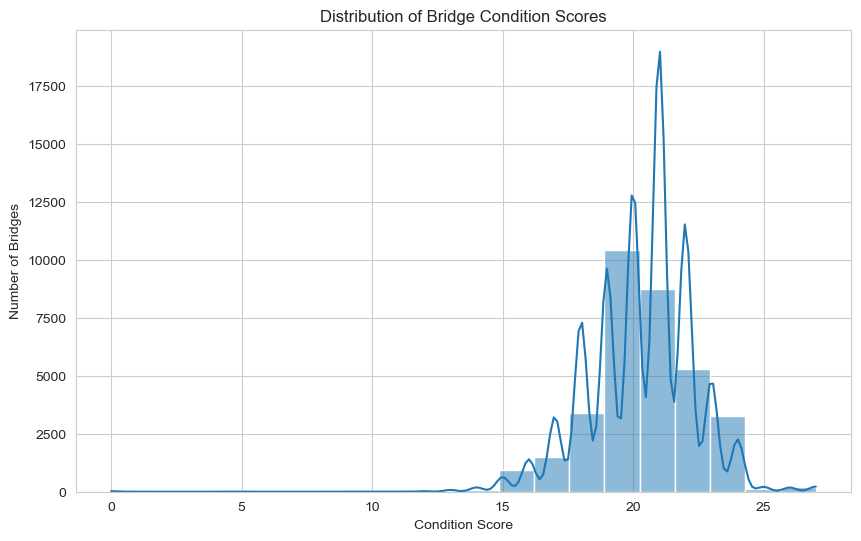

In [11]:
# Plot histogram to visualize distribution of 'Condition' scores
plt.figure(figsize=(10, 6))
sns.histplot(data=data_copy, x='Condition', bins=20, kde=True)
plt.title('Distribution of Bridge Condition Scores')
plt.xlabel('Condition Score')
plt.ylabel('Number of Bridges')
plt.show()

**Comments:**
The histogram shows a normal distribution where the majority of bridges are clustered around the 6, 7, and 8 scores corresponding to the 'Satisfactory', 'Good', and 'Very Good' ratings. This means that most bridges are in a good condition. There is a slightly left-skewed tail in the distribution which comes to represent the progressively worse number of bridges.

### 2.2 Continuous Predictors (Age, AverageDaily, Trucks_percent) vs Condition

To assess the influence of the numerical predictors with a higher degree of reliability, we can quantify the strength and direction of their relationship with the Condition score by calculating the correlation coefficients and significance values.

Scatter plots and Pearson correlation coefficients are used to assess the linear relationship between each continuous predictor and the Condition score. Following the individual plots, a heatmap summarises all pairwise correlations at a glance.

The Pearson Correlation Coefficient (r) ranges from -1 to 1:

- A (r > 0) is a positive correlation, as one variable increases, the other tends to increase. 
- A (r < 0) is a negative correlation, as one variable increases, the other one tends to decrease. 
- An r approximately equal to 1 denotes a very strong relationship. 
- An r approximately equal to 0 is a very weak or non-existent relationship.

We will also calculate the p-value (significance) for the correlations. The p-value represents the probability that the relationship result is due to chance. Typically, a p-value less than 0.05 (5%) indicates a statistically significant result, suggesting the observed effect is unlikely to be due to random chance with a 95% of probability.

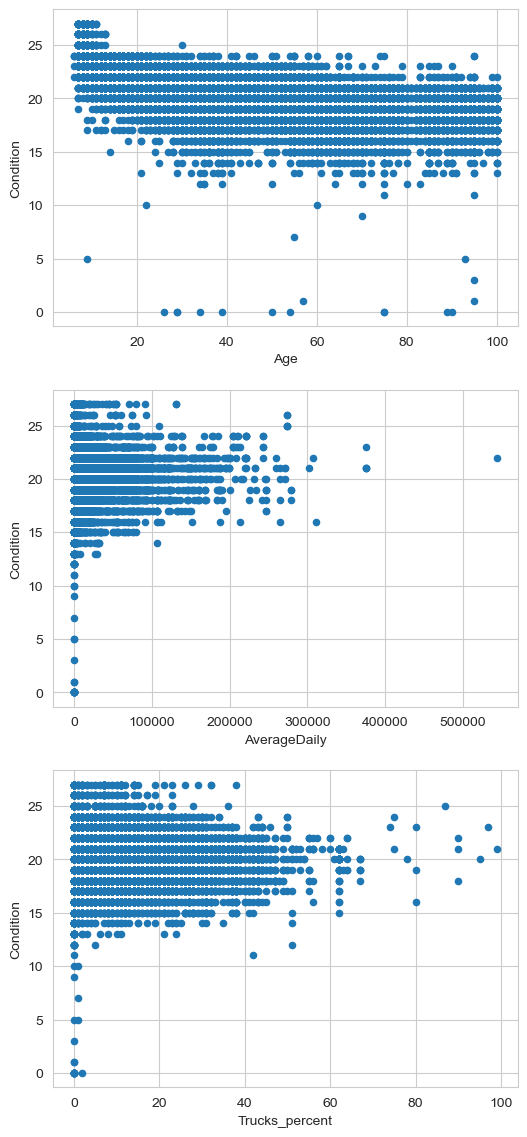

In [12]:
# Scatter plots to observe the relationship between Continuous Predictors and Condition
fig, (a1,a2,a3) = plt.subplots(3, 1, figsize=(6,14))
data_copy.plot(kind='scatter',  x='Age', y='Condition', ax=a1)
data_copy.plot(kind='scatter',  x='AverageDaily', y='Condition', ax=a2)
data_copy.plot(kind='scatter',  x='Trucks_percent', y='Condition', ax=a3)
plt.show()

**Comments:** The Age vs Condition scatter plot seems to show a cloud sloping downward, a trend barely visible which may indicate a negative relationship between Age and Condition, as the age increases, the Condition score tends to decrease. 

The AverageDaily vs Condition plot show no clear relationship, the data forms a cloud clustered around ~100,000 daily vehicles with Condition scores around 6-8, so in good states. Bridge traffic may be correlated with higher maintenance so there might not be a direct relationship with deterioration.

Trucks_percent vs Condition shows data concentrated around 0-20% of trucks with no visible slope. Condition scores are clustered around 5-8 across trucks percentage. As with the average use, the predictive value of the percentage of trucks seems weak, there is no discernible pattern which might suggest that the quantity of trucks affects the condition of bridges.

In [13]:
# Calculate correlation coefficient and p-value for Predictor variables
age_corr, age_p_value = pearsonr(data_copy['Age'], data_copy['Condition'])
avg_daily_corr, avg_daily_p_value = pearsonr(data_copy['AverageDaily'], data_copy['Condition'])
trucks_pct_corr, trucks_pct_p_value = pearsonr(data_copy['Trucks_percent'], data_copy['Condition'])

age_var_score = age_corr ** 2
daily_var_score = avg_daily_corr ** 2
trucks_var_score = trucks_pct_corr ** 2

print('Correlation Results:\n')
print(f'Correlation between Age and Condition:') 
print(f'Correlation (r): {age_corr:.4f}, P-value: {age_p_value:.4f}')
print(f'Variance explained: {age_var_score*100:.2f}%\n')
print(f'Correlation between Average Use and Condition:') 
print(f'Correlation (r): {avg_daily_corr:.4f}, P-value: {avg_daily_p_value:.4f}')
print(f'Variance explained: {daily_var_score*100:.2f}%\n')
print(f'Correlation between Percentage of Trucks and Condition:') 
print(f'Correlation (r): {trucks_pct_corr:.4f}, P-value: {trucks_pct_p_value:.4f}')
print(f'Variance explained: {trucks_var_score*100:.2f}%')


Correlation Results:

Correlation between Age and Condition:
Correlation (r): -0.5907, P-value: 0.0000
Variance explained: 34.89%

Correlation between Average Use and Condition:
Correlation (r): 0.0343, P-value: 0.0000
Variance explained: 0.12%

Correlation between Percentage of Trucks and Condition:
Correlation (r): -0.0490, P-value: 0.0000
Variance explained: 0.24%


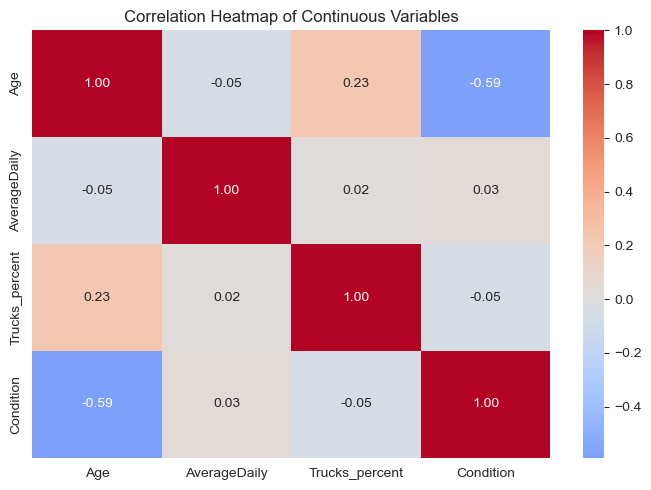

In [15]:
corr = data_copy[['Age', 'AverageDaily', 'Trucks_percent', 'Condition']].corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Continuous Variables')
plt.tight_layout()
plt.show()

**Comments:** The Age variable has a moderate to strong negative correlation with Condition, it explains nearly 35% of the variation, and the likelihood that this is due to chance is 0.0 according to the p-value. This means that the relationship is statistically significant, from which we can infer that age is clearly an influential predictor.

Average Use has a statistically significant positive correlation with Condition, however, the strength of this relationship is tiny, about 0.12% of the variation, to be seriously considered relevant. This means that even though the relationship is real, the influence on Condition is negligible.

In a similar fashion, Percentage of Trucks is statistically significant but has a very weak negative correlation.

### 2.3 Categorical Predictors vs Condition (Material, Design)

Material and Design are nominal variables, their categories are labels with no quantitative value, there is no inherent order so calculating a correlation coefficient for these values is not possible. Therefore, we will analyze these predictors in two ways: (1) We will use a box plot to visually compare the distribution of Condition scores for each category, (2) we will perform an ANOVA (Analysis of Variance) to quantify the difference between the average condition scores of the categorical values within Material and Design.

ANOVA calculates whether the average condition is really different between material types or design types and if those differences are due to random chance. This results in an F-Statistic value which compares the variation between groups to the variation within groups. A high f-statistic would indicate that the differences between groups are significant. Conversely, a low f-statistic would mean that the variation between groups is similar to the variation within groups, therefore, the differences could be random noise and the groups do not have a significant effect.

In [16]:
# Counts for each category within Material and Design
material_counts = data_copy['Material'].value_counts()
design_counts = data_copy['Design'].value_counts()

def print_counts(title, counts):
    print(f"\n{title}")
    print("-" * len(title))
    for category, count in counts.items():
        print(f"{category:12} {count}")

print_counts("Material Counts", material_counts)
print_counts("Design Counts", design_counts)


Material Counts
---------------
Concrete     26892
Steel        6557
Timber       465
Other        56

Design Counts
-------------
Beam         28206
Slab         4215
Other        1549


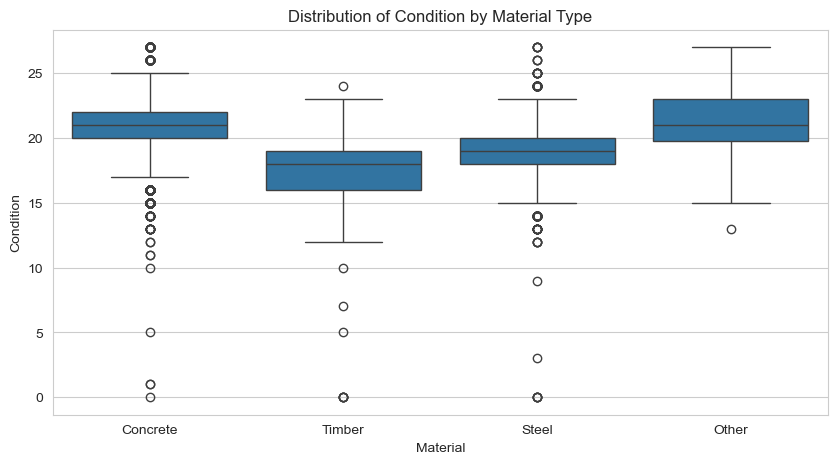

F-Statistic: 3936.5694
P-value: 0.0000

Mean Condition - Concrete: 20.6721
Mean Condition - Steel: 19.0845
Difference in means: 1.5876

Eta-squared (η²): 0.1053
Variance explained: 10.53%

Interpretation: Medium effect


In [17]:
# Distribution of Condition for each category of Material
plt.figure(figsize=(10, 5))
sns.boxplot(data=data_copy, x='Material', y='Condition')
plt.xlabel('Material')
plt.ylabel('Condition')
plt.title('Distribution of Condition by Material Type')
plt.show()

# We focus on the two largest groups for a clearer comparison
# Create groups for Condition scores where Material is 'Concrete' or 'Steel'
condition_concrete = data_copy[data_copy['Material'] == 'Concrete']['Condition']
condition_steel = data_copy[data_copy['Material'] == 'Steel']['Condition']

# Calculate F-statistic and p-value for the two groups 
f_statistic, p_value = f_oneway(condition_concrete, condition_steel)

# Calculate means for Concrete and Steel
mean_concrete = condition_concrete.mean()
mean_steel = condition_steel.mean()
grand_mean = pd.concat([condition_concrete, condition_steel]).mean()

# Sample sizes
n_concrete = len(condition_concrete)
n_steel = len(condition_steel)
n_total = n_concrete + n_steel

# Calculate Sum of Squares Between (SSB)
ssb = n_concrete * (mean_concrete - grand_mean)**2 + n_steel * (mean_steel - grand_mean)**2

# Calculate Sum of Squares Total (SST)
all_values = pd.concat([condition_concrete, condition_steel])
sst = np.sum((all_values - grand_mean)**2)

# Eta-squared
eta_squared = ssb / sst

def interpret_effect_size(eta_sq):
    if eta_sq < 0.01:
        return "Negligible - practically meaningless"
    elif eta_sq < 0.06:
        return "Small effect"
    elif eta_sq < 0.14:
        return "Medium effect"
    else:
        return "Large effect"

print(f'F-Statistic: {f_statistic:.4f}')
print(f'P-value: {p_value:.4f}')
print(f"\nMean Condition - Concrete: {mean_concrete:.4f}")
print(f"Mean Condition - Steel: {mean_steel:.4f}")
print(f"Difference in means: {abs(mean_concrete - mean_steel):.4f}")
print(f"\nEta-squared (η²): {eta_squared:.4f}")
print(f"Variance explained: {eta_squared * 100:.2f}%")
print(f"\nInterpretation: {interpret_effect_size(eta_squared)}")


**Comments:** The box plot shows that 'Steel' bridges have a lower median and wider distribution than 'Concrete' bridges. The mean distribution for Concrete bridges clusters tightly around the 7 while Steel bridges are closer to 6. This suggests that Concrete tends to be in slightly better condition than Steel on average.

The F-statistic (3943.73) shows a very big ratio which means that the variation between the type of Material, 'Concrete' vs 'Steel', is bigger than the variation within each group. So, the type of Material is a highly influential predictor of Condition. 

The p-value, which tells us the probability that the results are due to chance is effectively 0.00. The eta-squared measures how much of the variation can be explained by the material type. In this case, approximately 10% of the differences observed in condition scores come from the type of material used. The effect is not small but it is not huge either, there are other meaningful factors playing a significant role in the condition.

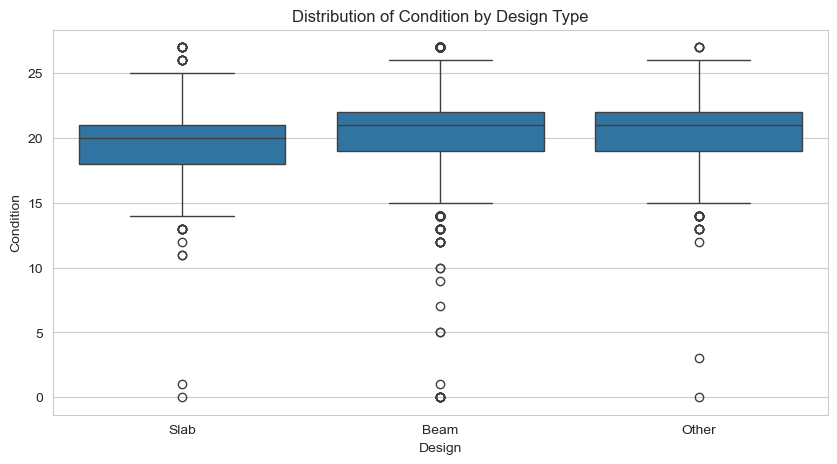

F-Statistic: 443.1368
P-value: 0.0000

Mean Condition - Beam: 20.3985
Mean Condition - Slab: 19.7231
Difference in means: 0.6753

Eta-squared (η²): 0.0135
Variance explained: 1.35%

Interpretation: Small effect


In [18]:
# Distribution of Condition for each category of Design
plt.figure(figsize=(10, 5))
sns.boxplot(data=data_copy, x='Design', y='Condition')
plt.xlabel('Design')
plt.ylabel('Condition')
plt.title('Distribution of Condition by Design Type')
plt.show()

# Create groups for Condition scores where Design is 'Beam' or 'Slab'
condition_beam = data_copy[data_copy['Design'] == 'Beam']['Condition']
condition_slab = data_copy[data_copy['Design'] == 'Slab']['Condition']

# Calculate F-statistic and p-value for the two groups 
f_statistic, p_value = f_oneway(condition_beam, condition_slab)

# Calculate means for Beam vs Slab
mean_beam = condition_beam.mean()
mean_slab = condition_slab.mean()
grand_mean = pd.concat([condition_beam, condition_slab]).mean()

# Sample sizes
n_beam = len(condition_beam)
n_slab = len(condition_slab)
n_total = n_beam + n_slab

# Calculate Sum of Squares Between (SSB)
ssb = n_beam * (mean_beam - grand_mean)**2 + n_slab * (mean_slab - grand_mean)**2

# Calculate Sum of Squares Total (SST)
all_values = pd.concat([condition_beam, condition_slab])
sst = np.sum((all_values - grand_mean)**2)

# Eta-squared
eta_squared = ssb / sst

def interpret_effect_size(eta_sq):
    if eta_sq < 0.01:
        return "Negligible - practically meaningless"
    elif eta_sq < 0.06:
        return "Small effect"
    elif eta_sq < 0.14:
        return "Medium effect"
    else:
        return "Large effect"

print(f'F-Statistic: {f_statistic:.4f}')
print(f'P-value: {p_value:.4f}')
print(f"\nMean Condition - Beam: {mean_beam:.4f}")
print(f"Mean Condition - Slab: {mean_slab:.4f}")
print(f"Difference in means: {abs(mean_beam - mean_slab):.4f}")
print(f"\nEta-squared (η²): {eta_squared:.4f}")
print(f"Variance explained: {eta_squared * 100:.2f}%")
print(f"\nInterpretation: {interpret_effect_size(eta_squared)}")

**Comments:** 
- The box plot shows that 'Slab' designs appear to have a lower median condition and be more varied than 'Beam' designs.
 
- The F-Statistic is large (503.63), meaning there are differences among designs. Beams are in slightly better condition than slabs. The p-value is effectively 0.00 so this suggests that Design is also an influential predictor of Condition. However, the design type explains only about 1.5% of why some bridges are in better condition than others, most of the variation comes from other factors, so it is a minor influence compared to age and material.

### 2.4 Relationships Between Predictors

Before building the regression model, it is important to examine whether the predictor variables are correlated with each other. If two predictors move 
together strongly, the regression model may struggle to isolate the individual effect of each. The scatter matrix below shows all pairwise relationships between continuous predictors.

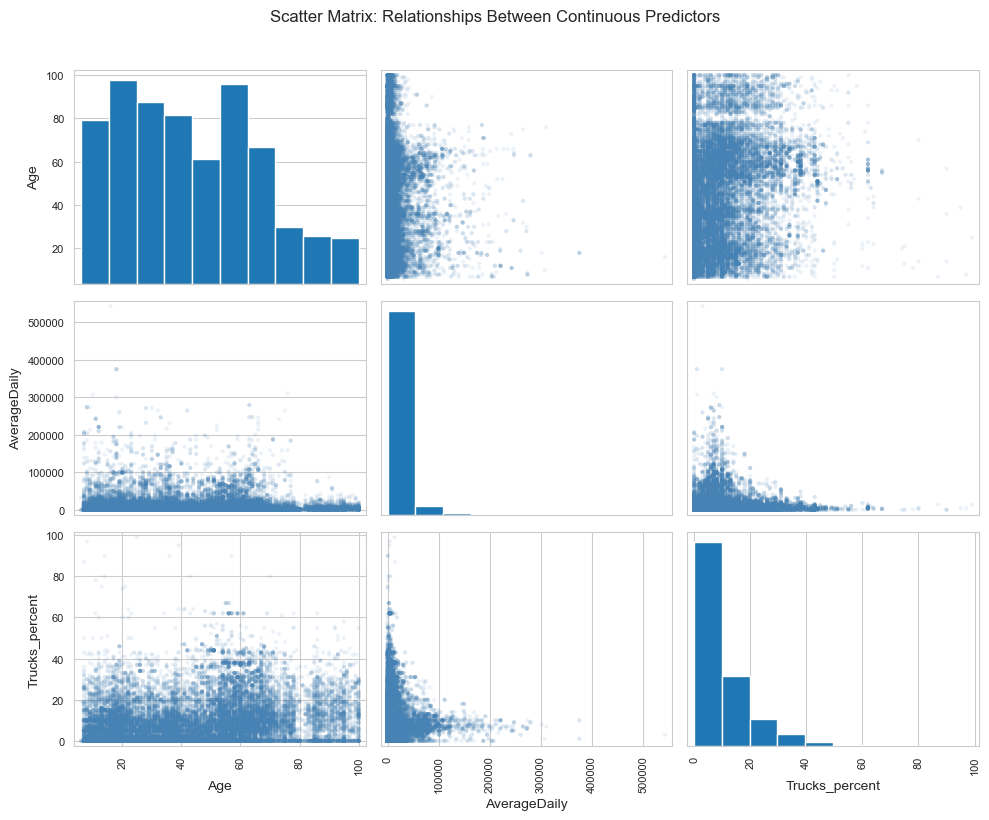

In [21]:
from pandas.plotting import scatter_matrix

scatter_matrix(
    data_copy[['Age', 'AverageDaily', 'Trucks_percent']],
    alpha=0.1, figsize=(10, 8), diagonal='hist', color='steelblue'
)
plt.suptitle('Scatter Matrix: Relationships Between Continuous Predictors', y=1.02)
plt.tight_layout()
plt.show()

The cross-tabulation below shows how many bridges share each combination of 
material and design type. A strong concentration in one cell would suggest 
that the two variables are not independent of each other, for example, if 
steel bridges almost always use a beam design.

Design     Beam  Other  Slab
Material                    
Concrete  21623   1054  4215
Other         0     56     0
Steel      6119    438     0
Timber      464      1     0


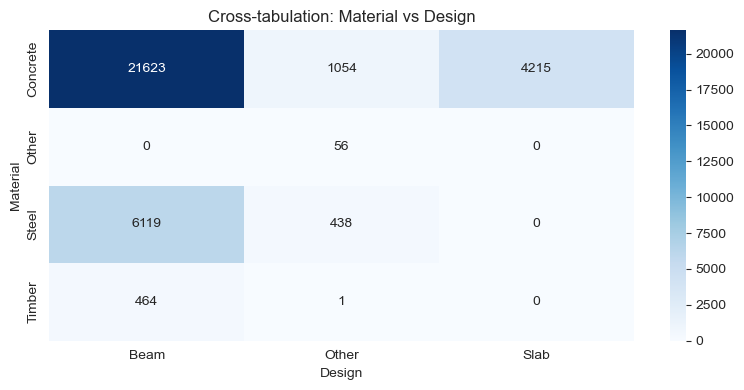

In [22]:
crosstab = pd.crosstab(data_copy['Material'], data_copy['Design'])
print(crosstab)

# Visualise as heatmap
plt.figure(figsize=(8, 4))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='Blues')
plt.title('Cross-tabulation: Material vs Design')
plt.tight_layout()
plt.show()

Concrete bridges overwhelmingly use beam design, same with steel bridges. This overlap means Material and Design are not 
fully independent, a pattern worth noting when interpreting the 
regression coefficients.

### 2.5 Preliminary Conclusions

Based on this exploratory analysis, we can preliminary assume that age may have the highest influence on the condition of bridges. This is because age shows a strong to moderate statistically significant negative correlation with condition. Although both age and material highly affect the condition, age seems the stronger predictor. It explains approximately 35% of why conditions differ, in comparison, material explains about 10% of the differences in condition. 

Design shows a large f-statistic and a tiny p-value score but it explains only 1.5% of the variance, it has a negligible influence on bridge condition. AverageDaily and Trucks_percent have both negligible correlations with condition, no practical influence.

<hr style="height:2px; border:none; background-color: #3498db;">

## Part 3: Regression Modelling

In this final section, we will build a linear regression model to look at the effect of the five predictor variables on the target variable and answer the questions with final conclusions regarding which variable has a greater influence on the condition of bridges and how accurate the proposed predictor variables are in predicting the bridge condition.

### 3.1 Model Construction

A multiple linear regression model is fitted using all five predictor variables. The categorical variables **Material** and **Design** are encoded as dummy variables (one category per variable is used as a reference baseline to avoid redundancy). The model estimates a separate coefficient for each predictor, representing the expected change in Condition score for a one-unit change in that predictor, holding all others constant.

**Note:** Several Design categories (Arch, Frame, Movable, Suspension, Truss) have coefficients of 0.0. This is due to perfect multicollinearity, as seen in the cross-tabulation in Section 2.4, these design types are almost exclusively associated with a single material category. Scikit-learn's `LinearRegression` silently zeroes out such collinear features. These categories have too few observations to be independently estimated and their effect is absorbed by the material coefficients.

In [23]:
# Create new DataFrame with dummy variables for Material and Design
data_copy['Material'] = pd.Categorical(data_copy['Material'], categories=['Concrete', 'Steel', 'Timber', 'Other', 'Masonry'])
data_copy['Design'] = pd.Categorical(data_copy['Design'], categories=['Beam', 'Slab', 'Arch', 'Truss', 'Other', 'Frame', 'Movable', 'Suspension'])

data_with_dummies = pd.get_dummies(data_copy, columns=['Material', 'Design'], drop_first=True)

print(data_with_dummies)

          Structure_id    District  Detour_Km  Toll Maintainer  Urban Status  \
0      000021521-00101   District2        199  Free     Agency  Rural  Local   
1      000021521-00181   District2        199  Free     Agency  Rural  Local   
2      000021521-TMP20   District2        199  Free     Agency  Rural  Local   
3      000021525-00012   District2        199  Free     Agency  Rural  Local   
4      000021580-00092   District2          6  Free     Agency  Rural  Local   
...                ...         ...        ...   ...        ...    ...    ...   
34288  DAPFORHOO000012   District9          0  Free   Military  Urban  Local   
34289  DAPFORHOO000013   District9          0  Free   Military  Urban  Local   
34290  DAPFORHOO000015   District9          0  Free   Military  Urban  Minor   
34291  DAPFORHOO00005A   District9          0  Free   Military  Urban  Local   
34292  DAPTRABLI000011  District24         14  Free   Military  Urban  Minor   

       Year  Lanes_on  Lanes_under  ...

To avoid data leakage, we will create a list of only the columns we are using, these are: our 3 continuous predictors and the new dummy columns.

In [24]:
# Get columns for predictor variables
pred_columns = ['Age', 'AverageDaily', 'Trucks_percent', 'Material_Masonry', 'Material_Other', 'Material_Steel',
       'Material_Timber', 'Design_Arch', 'Design_Frame', 'Design_Movable',
       'Design_Other', 'Design_Slab', 'Design_Suspension', 'Design_Truss']

# Define target variable
y = data_with_dummies['Condition']

# Define predictor variables
X = data_with_dummies[pred_columns]
X

,Age,AverageDaily,Trucks_percent,Material_Masonry,Material_Other,Material_Steel,Material_Timber,Design_Arch,Design_Frame,Design_Movable,Design_Other,Design_Slab,Design_Suspension,Design_Truss
0,20,1,0.0,False,False,False,False,False,False,False,False,True,False,False
1,20,1,0.0,False,False,False,False,False,False,False,False,True,False,False
2,13,100,0.0,False,False,False,False,False,False,False,False,False,False,False
3,75,80,0.0,False,False,False,True,False,False,False,False,False,False,False
4,21,150,4.0,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34288,31,300,40.0,False,False,False,False,False,False,False,False,False,False,False
34289,25,300,40.0,False,False,False,False,False,False,False,False,False,False,False
34290,29,1200,25.0,False,False,False,False,False,False,False,False,False,False,False
34291,34,300,15.0,False,False,False,False,False,False,False,False,False,False,False


We will feed the data to the linear regression algorithm where the model will find the optimal coefficients for each of the predictors.

In [25]:
# Instantiate model
model = LinearRegression()

# Train the model
model.fit(X, y)

coefficients = list(zip(pred_columns, model.coef_))
sorted_coefficients = sorted(coefficients, key=lambda x: x[1], reverse=True)

print(f'Model intercept: {model.intercept_}')
print(f'Model coefficients: {model.coef_}\n')

for feature, coef in sorted_coefficients:
    print(f'{feature}: {coef:.4f}')

Model intercept: 22.724130042330692
Model coefficients: [-4.93419451e-02 -7.95538706e-07  5.08853560e-03 -1.11022302e-16
  1.31669499e-01 -1.37263705e+00 -3.18811480e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00 -1.67885963e-02 -7.47979288e-02
  0.00000000e+00  0.00000000e+00]

Material_Other: 0.1317
Trucks_percent: 0.0051
Design_Arch: 0.0000
Design_Frame: 0.0000
Design_Movable: 0.0000
Design_Suspension: 0.0000
Design_Truss: 0.0000
Material_Masonry: -0.0000
AverageDaily: -0.0000
Design_Other: -0.0168
Age: -0.0493
Design_Slab: -0.0748
Material_Steel: -1.3726
Material_Timber: -3.1881


**Comments:** 
- A bridge that is 0 years old and has the features of the baseline categories ('Concrete' material, 'Beam' design) is predicted to have a condition score of **22.72** according to the model intercept. For every year a bridge gets older, its Condition score is predicted to decrease by **0.0162**, all other factors being equal. 

- AverageDaily's coefficient is effectively 0.00 and the effect of percentage of trucks is predicted to be very small or near zero, so these variables are confirmed to have no meaningful influence. 

- A 'Steel' bridge is predicted to have a Condition score 0.459 lower than the baseline, a 'Concrete' bridge. A 'Timber' bridge is predicted to be 1.03 points lower than a 'Concrete' bridge. In contrast, 'Masonry' bridges are expected to have a Condition score about 0.14 points higher than the baseline.

- 'Slab', 'Truss', and 'Other' designs are predicted to have moderate negative effects compared to the baseline, 'Beam' designs. 'Movable' designs have the highest negative impact, about 0.43 points lower compared to the baseline. 'Suspension' bridges have the highest positive effect on condition compared to 'Beam' bridges, followed by 'Arch' designs with 0.37, and 'Frame' designs with a small positive 0.062 points. 

### 3.2 Model Performance

Two metrics are used to evaluate how well the model fits the data:

- **R² (coefficient of determination):** the proportion of variation in 
  Condition that the model explains. A value of 1.0 would mean perfect 
  prediction; 0.0 would mean the model does no better than simply 
  predicting the average for every bridge.
- **RMSE (root mean squared error):** the average size of a prediction 
  error, expressed in the same units as Condition (0–27 scale). 
  An RMSE of 2.5, for example, means predictions are typically off 
  by about 2.5 condition points.

The predicted vs actual plot below shows how closely the model's 
predictions match the real observed values. Points lying on the 
red dashed line represent perfect predictions.

In [26]:
# Predictions for the test set
y_pred = model.predict(X)

r_squared = model.score(X, y)

mse = mean_squared_error(y, y_pred)

print(f'R-squared: {r_squared:.4f}')
print(f'Mean Squared Error: {mse:.4f}')

R-squared: 0.4541
Mean Squared Error: 2.1590


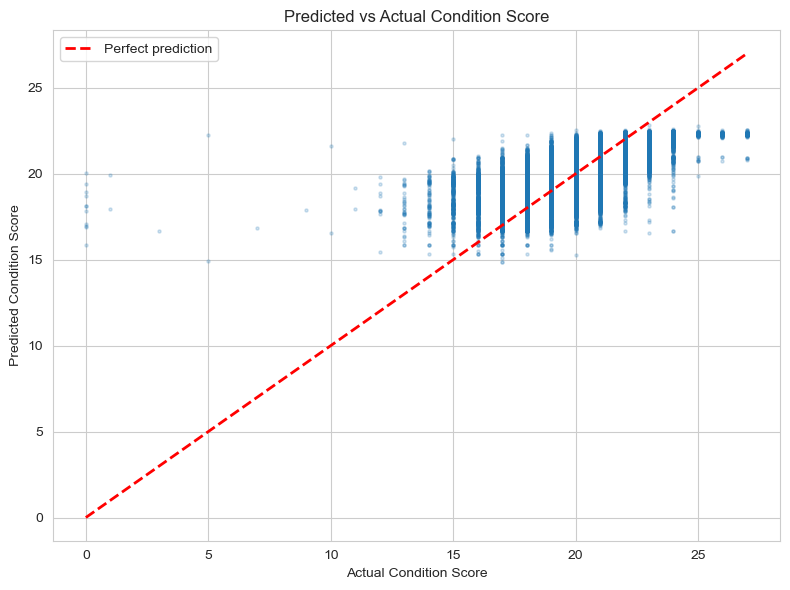

In [27]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y, y_pred, alpha=0.2, s=5)
ax.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect prediction')
ax.set_xlabel('Actual Condition Score')
ax.set_ylabel('Predicted Condition Score')
ax.set_title('Predicted vs Actual Condition Score')
ax.legend()
plt.tight_layout()
plt.show()

**Comments:** 
- The R-squared measures the proportion of the variance in the Condition score that the model is able to explain. This means that using these predictors, the linear regression model can explain 46% of why bridge Condition scores change. Therefore, most variance in condition scores (54%) are caused by other factors outside the predictor variables.

- The Mean Squared Error measures the averaged squared difference between actual and predicted values. This means our model's prediction of a bridge's condition is off by 0.2358 ≈ $\pm$ 0.49 condition points.

### 3.3 Residual Analysis

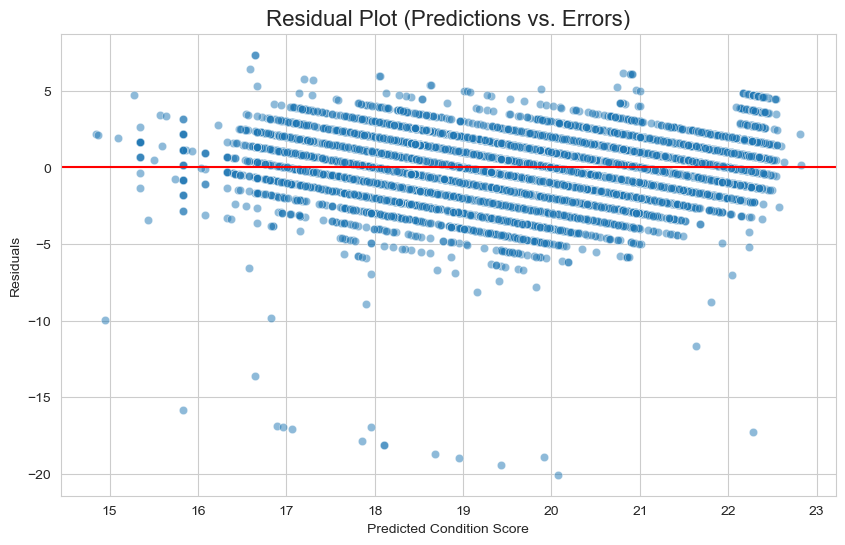

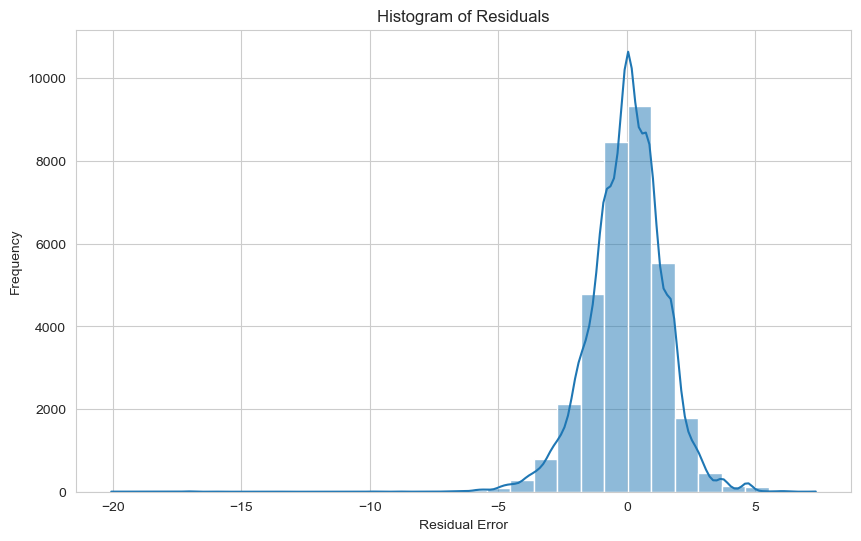

In [29]:
# Calculate the errors, difference between actual values and predictions
residuals = y - y_pred

# Residual scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.5)
plt.axhline(0, color='red') 
plt.title('Residual Plot (Predictions vs. Errors)', fontsize=16)
plt.xlabel('Predicted Condition Score')
plt.ylabel('Residuals')
plt.show()

# Histogram of Residuals
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, bins=30)
plt.title('Histogram of Residuals')
plt.xlabel('Residual Error')
plt.ylabel('Frequency')
plt.show()

**Comments:**

- The plot shows the residuals are clustered in a mostly random cloud around the red line (0 error). There is no obvious funnel shape or clear curve. This suggests that our linear regression model is a reasonable and valid choice for this problem, and we can trust the performance metrics.

- The Histogram of Residuals shows an approximately normal (bell-shaped) distribution. This suggests that the assumptions of linear regression are met and our model is valid

### 3.4 Predictor Influence

The raw regression coefficients cannot be directly compared to each other 
because the predictors are measured on different scales: Age in years, 
AverageDaily in vehicles per day, and Condition on a 0–27 scale. 

To make a fair comparison, the predictors are standardised (converted to 
the same scale) before fitting a second model. The resulting standardised 
coefficients represent the expected change in Condition score (in standard 
deviations) for a one standard deviation increase in each predictor. A larger 
absolute value means greater influence on bridge condition.

        Predictor  Standardised Coefficient
              Age             -1.144463e+00
   Material_Steel             -5.417402e-01
  Material_Timber             -3.704415e-01
   Trucks_percent              5.270645e-02
      Design_Slab             -2.465885e-02
     AverageDaily             -1.935166e-02
   Material_Other              5.341622e-03
     Design_Other             -3.502336e-03
 Material_Masonry             -5.551115e-17
      Design_Arch              2.775558e-17
     Design_Frame              0.000000e+00
   Design_Movable              0.000000e+00
Design_Suspension              0.000000e+00
     Design_Truss              0.000000e+00


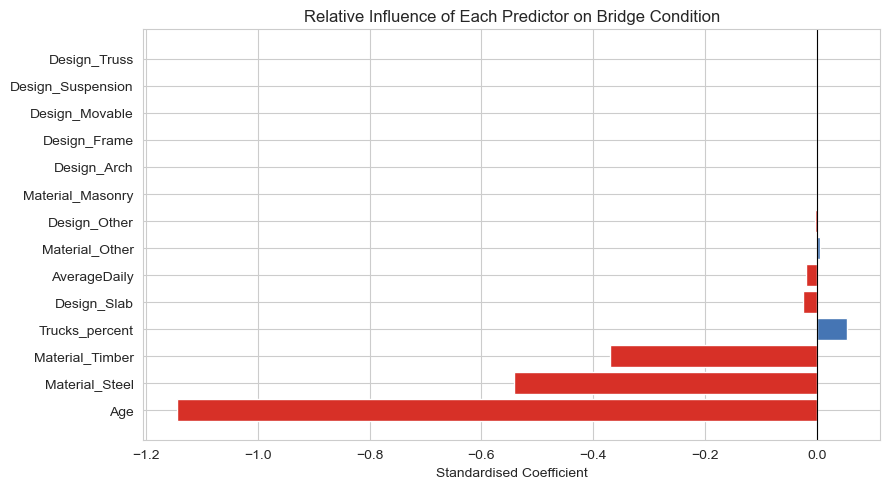

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model_std = LinearRegression()
model_std.fit(X_scaled, y)

influence = pd.DataFrame({
    'Predictor': X.columns,
    'Standardised Coefficient': model_std.coef_
}).sort_values('Standardised Coefficient', key=abs, ascending=False)

print(influence.to_string(index=False))

# Bar chart
plt.figure(figsize=(9, 5))
colours = ['#d73027' if c < 0 else '#4575b4' for c in influence['Standardised Coefficient']]
plt.barh(influence['Predictor'], influence['Standardised Coefficient'], color=colours)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Standardised Coefficient')
plt.title('Relative Influence of Each Predictor on Bridge Condition')
plt.tight_layout()
plt.show()

Age carries the largest standardised coefficient in magnitude, confirming 
it is the strongest predictor of condition. Among the categorical variables, 
material type has a meaningful effect, while traffic volume and truck 
percentage show negligible influence which is consistent with the exploratory 
findings in Part 2.

### 3.5 Final Conclusions

 - **Which of the proposed predictor variables has more influence on the current condition?**

The regression coefficients show that the average use and the percentage of trucks have no meaningful influence on Condition. This is further supported by their weak Pearson correlation coefficients in the exploratory analysis. 

Design has a more meaningful effect on Condition, it matters but not as strongly as Age or Material. The ANOVA test shows it only explains 1.5% of the variance and its regression coefficients show smaller shifts $\pm$ 0.4 than Age or Material predictors.

Material and Age seem to be the most dominant predictors. Their impact on Condition differs in the baseline effect vs the cumulative effect. Choosing to build a bridge out of Timber or Steel has a strong negative impact on the baseline condition of a bridge compared to a Concrete bridge. Specifically, Timber decreases Condition by 1.03 points and Steel decreases it by 0.46 points. Over time, Age has a cumulative large effect (-0.016 per year) but Material has a way higher immediate effect that might be equivalent to 50 years of aging. 

In conclusion, Material has the strongest baseline influence on the condition, followed by the cumulative effect of Age and then Design.

 - **How well do the proposed predictor variables predict the bridge condition?**

 The model predicts a bridge's condition with an average accuracy of $\pm$ 0.5 points on a 9-point scale. The predictors together explain about 46% of the variance in bridge conditions which suggests other factors like maintenance or interaction effects may also be important.